# 01 · Exploratory Data Analysis — UCI Heart Disease (Cleveland)

Goal: understand data quality, class balance and which clinical signals separate patients with and without heart disease, to inform cleaning and feature engineering.

In [1]:
import sys, pathlib
ROOT = pathlib.Path.cwd().parent if pathlib.Path.cwd().name == "notebooks" else pathlib.Path.cwd()
sys.path.insert(0, str(ROOT / "src"))
%matplotlib inline

In [2]:
from cardiorisk import config
from cardiorisk.data import prepare, load_raw, load_clean, missing_report
clean = prepare()
raw = load_raw()
print(raw.shape, '->', clean.shape)
raw.head()

(303, 14) -> (303, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


## Data quality
Missing values are encoded as `?` in the raw file. Only `ca` (4 rows) and `thal` (2 rows) are affected. They are **kept as NaN** and imputed *inside* the model pipeline so imputation statistics are learned on training folds only.

In [3]:
print(missing_report(raw))
clean.describe().T.round(2)

ca      4
thal    2
dtype: int64


,count,mean,std,min,25%,50%,75%,max
age,303.0,54.438944,9.038662,29.0,48.0,56.0,61.0,77.0
sex,303.0,0.679868,0.467299,0.0,0.0,1.0,1.0,1.0
cp,303.0,3.158416,0.960126,1.0,3.0,3.0,4.0,4.0
trestbps,303.0,131.689769,17.599748,94.0,120.0,130.0,140.0,200.0
chol,303.0,246.693069,51.776918,126.0,211.0,241.0,275.0,564.0
fbs,303.0,0.148515,0.356198,0.0,0.0,0.0,0.0,1.0
restecg,303.0,0.990099,0.994971,0.0,0.0,1.0,2.0,2.0
thalach,303.0,149.607261,22.875003,71.0,133.5,153.0,166.0,202.0
exang,303.0,0.326733,0.469794,0.0,0.0,0.0,1.0,1.0
oldpeak,303.0,1.039604,1.161075,0.0,0.0,0.8,1.6,6.2


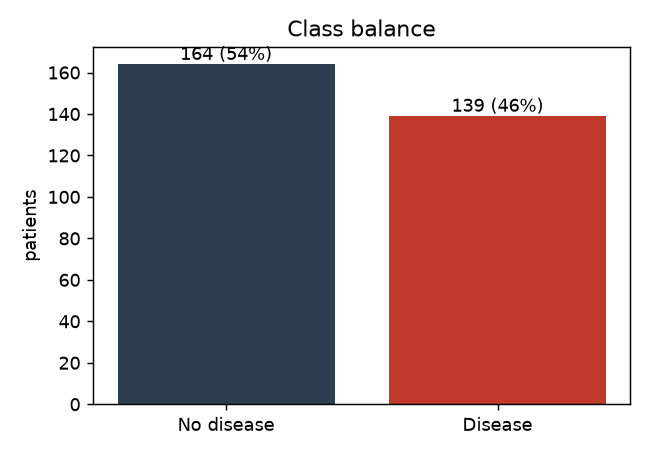

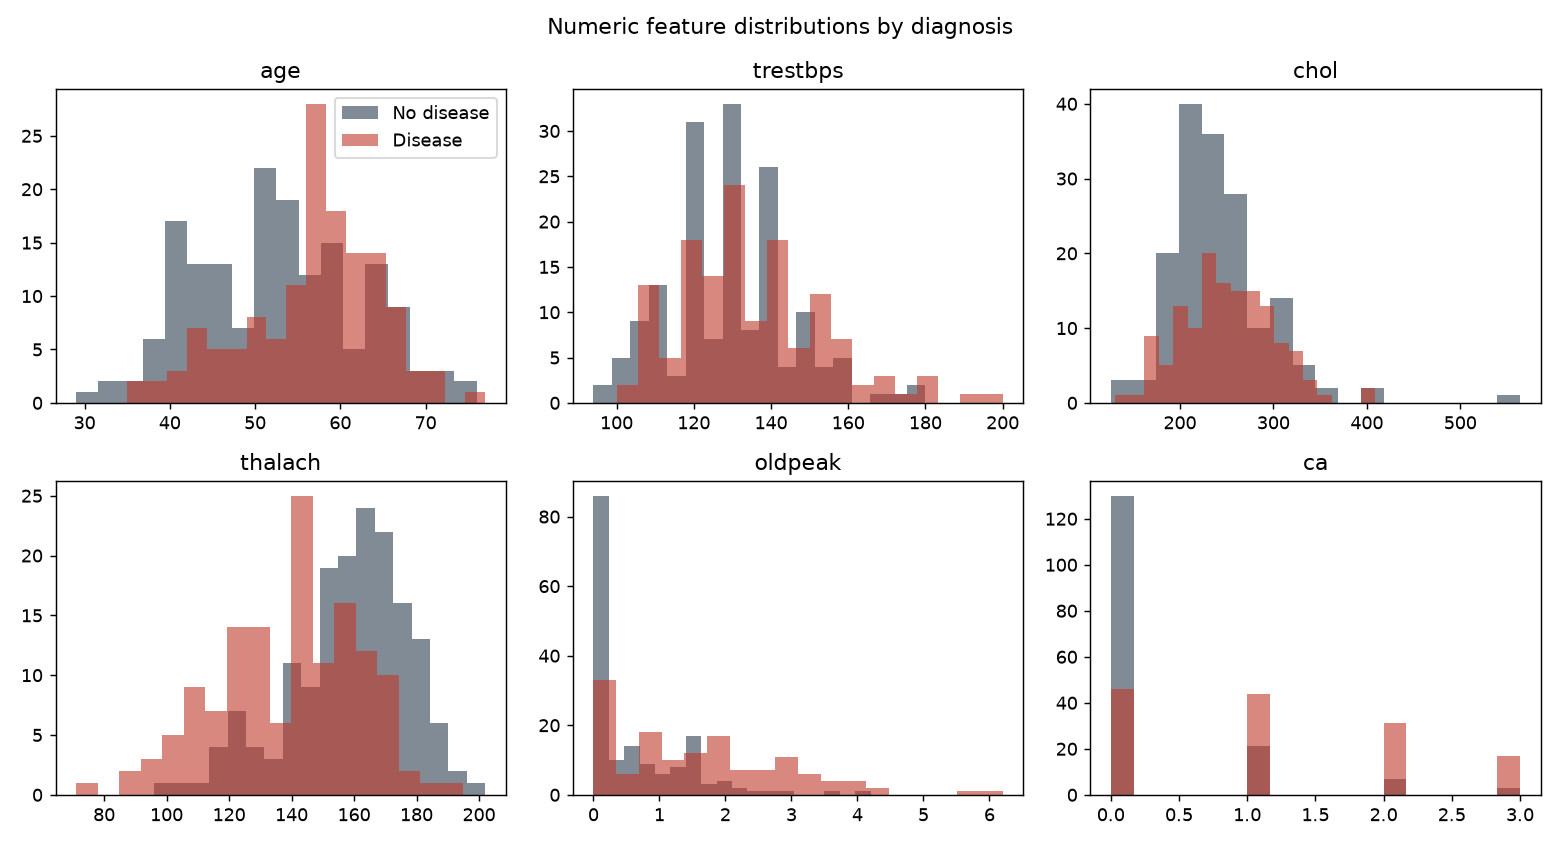

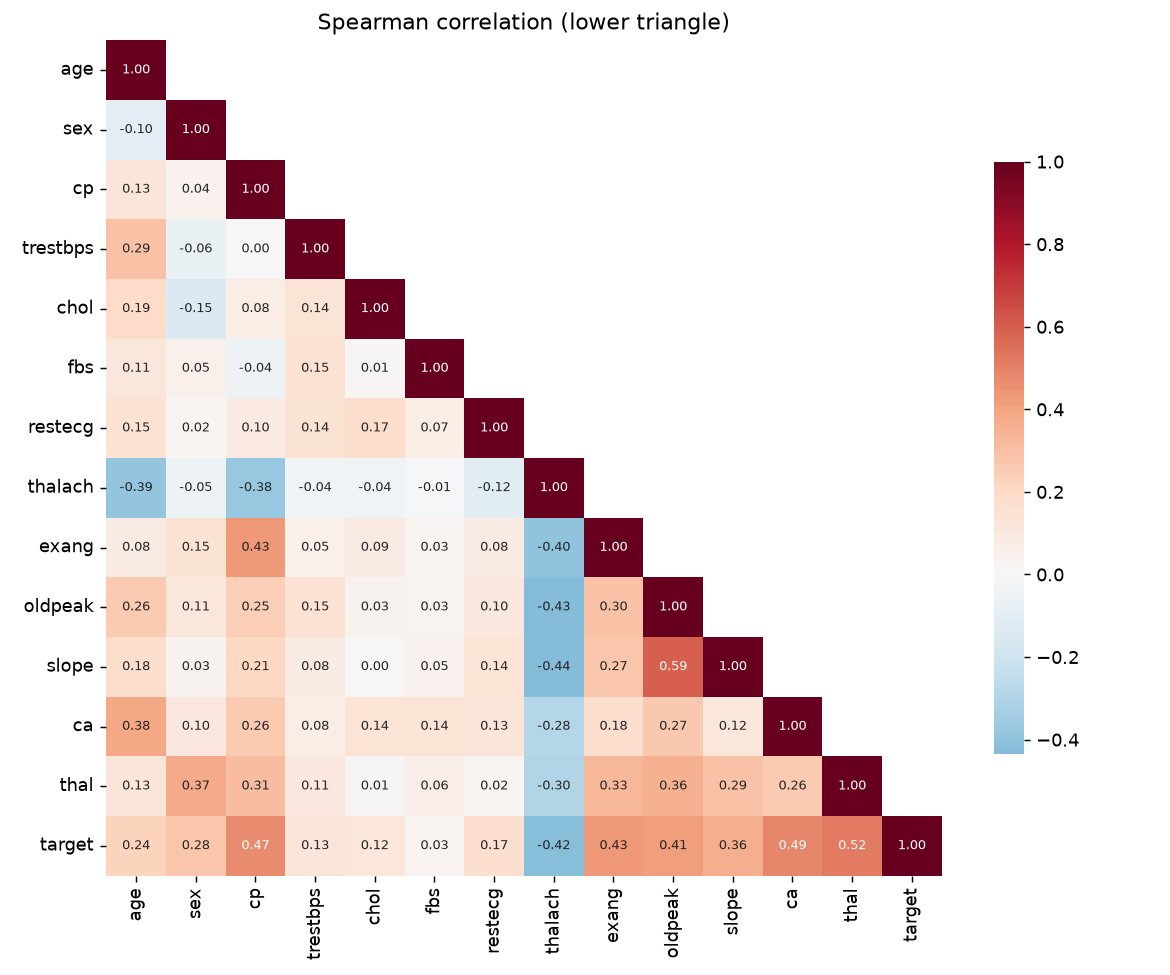

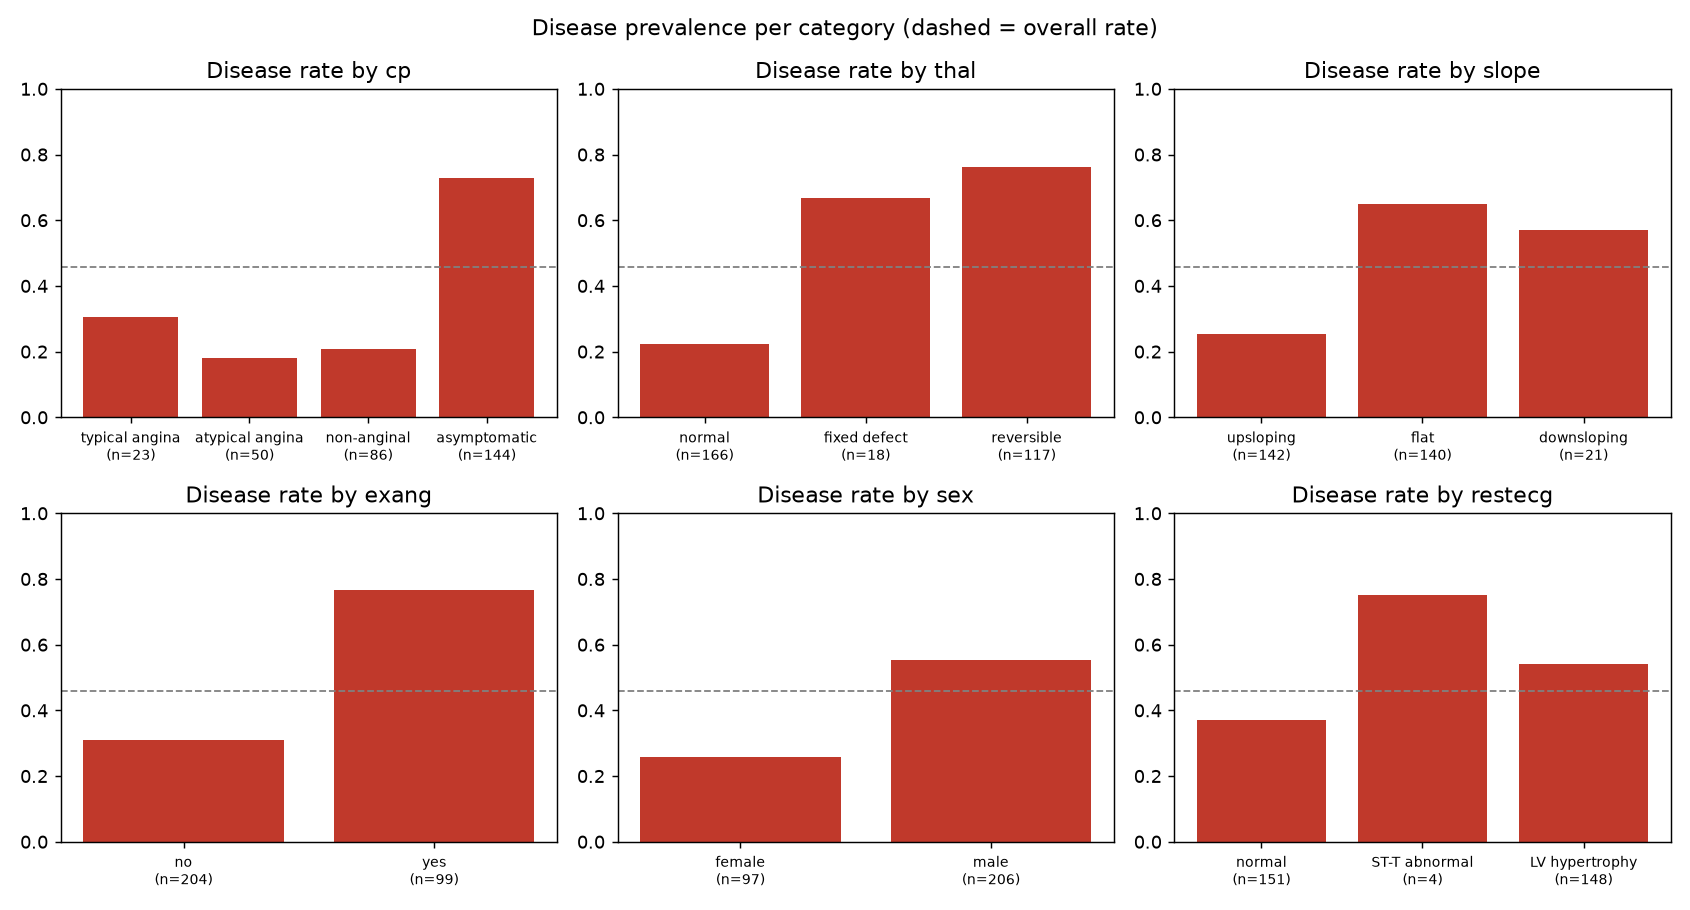

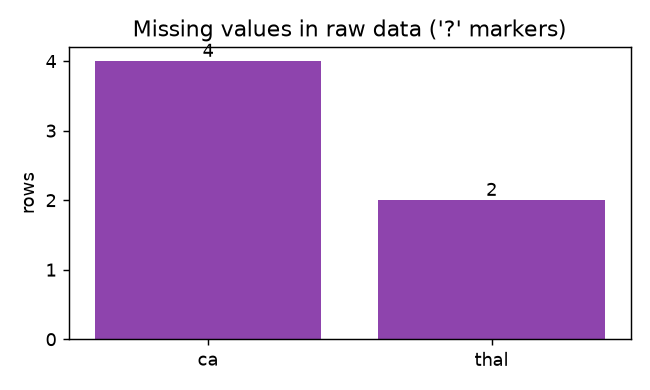

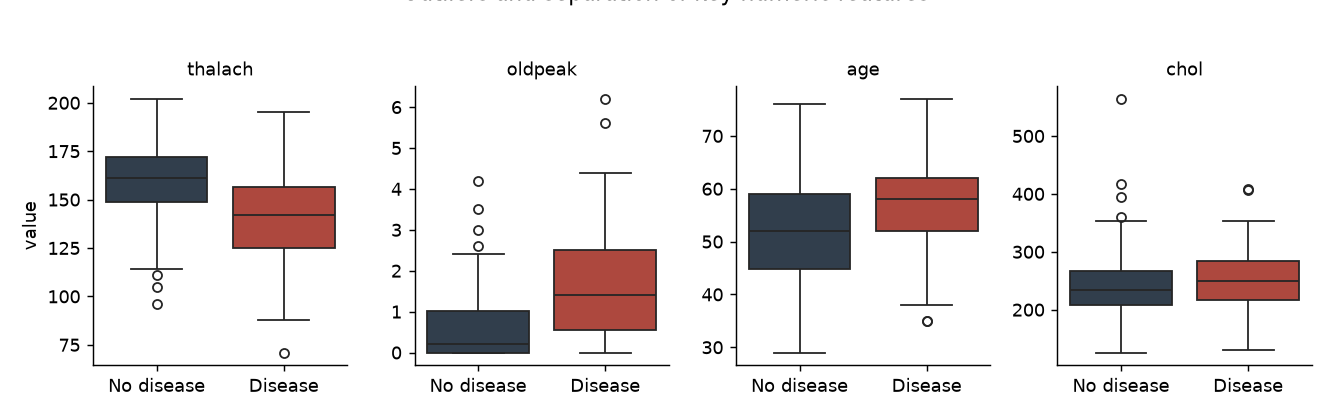

In [4]:
from IPython.display import Image, display
from cardiorisk.eda import run_all
paths = run_all(raw, clean)
for p in paths: display(Image(filename=str(p)))

## Target
`num` 0 = no disease, 1–4 = increasing severity. We collapse 1–4 into a single positive class (the standard binary formulation). The classes are close to balanced (≈46 % positive), so accuracy is meaningful, but we still report precision/recall/ROC-AUC.

In [5]:
clean[config.TARGET].value_counts(normalize=True).round(3)

target
0    0.541
1    0.459
Name: proportion, dtype: float64

## Strongest univariate signals

In [6]:
corr = clean.astype(float).corr(method='spearman')[config.TARGET].drop(config.TARGET)
corr.reindex(corr.abs().sort_values(ascending=False).index).round(3)

thal        0.522
ca          0.489
cp          0.472
exang       0.432
thalach    -0.423
oldpeak     0.413
slope       0.364
sex         0.277
age         0.237
restecg     0.169
trestbps    0.128
chol        0.121
fbs         0.025
Name: target, dtype: float64

## Takeaways that drive modelling
* `thal`, `ca`, `cp`, `oldpeak`, `exang` and `thalach` carry most of the signal; `chol` and `fbs` are weak.
* `cp`, `thal`, `slope`, `restecg` are **nominal** codes → one-hot encode, never treat as numbers.
* `thalach` falls with age, so a raw comparison is confounded. Engineered feature `hr_reserve_pct = thalach / (220 − age)` measures heart-rate response relative to the age-predicted maximum.
* Numeric scales differ by two orders of magnitude (oldpeak vs chol) → standardise for linear models.
* A few cholesterol/BP outliers are physiologically plausible, so they are kept (tree models are robust; the linear model sees them after scaling).